# Example 1C: Distribuição de Perdas Multi-Ano

## Apêndice A, Seção A5: Extensão para Múltiplos Períodos

Este notebook demonstra o modelo Credit Risk+ aplicado a um horizonte de múltiplos anos,
considerando que as taxas de default e exposições mudam ao longo do tempo.

## 1. Conceito: Horizonte de Risco Multi-Ano

Em um portfólio de crédito, as exposições evoluem:
- Obrigadores podem **quitador** (reduzir exposição)
- Taxas de default podem **variar** com ciclos econômicos
- Novos empréstimos podem ser **adicionados**

O modelo estende-se para múltiplos períodos (Eq. 37 do Apêndice A):
$$A^{(t)}_n = \frac{1}{n} \sum_{j=1}^m \varepsilon_j^{(t)} \times A^{(t)}_{n-v_j^{(t)}}$$

Onde o superscrito $(t)$ indica o período $t$ (ano 1, 2, 3, etc.).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../creditriskplus')

from simple_model import calculate_loss_distribution_simple
from data import create_example_1a_portfolio

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Estrutura a Termo das Taxas de Default

No Example 1C, consideramos taxas de default que variam por período.
Isso é comum em análises de horizonte de hold-to-maturity.

**Exemplo prático:**
- Ano 1: Obrigador tem rating B (1.6% default)
- Ano 2: Pode cair para C (3.0% default) em recessão
- Ano 3: Recupera para B novamente (1.6% default)

In [2]:
# Carrega portfolio base
portfolio_base = create_example_1a_portfolio()

# Simula estrutura a termo de taxas (alterando taxas por ano)
# Para simplicidade, usamos fatores de ajuste ano-a-ano
rate_term_structure = {
    1: 1.0,      # Ano 1: taxas base
    2: 1.3,      # Ano 2: 30% mais altas (recessão média)
    3: 0.9       # Ano 3: 10% menores (recuperação)
}

print("=== ESTRUTURA A TERMO DE TAXAS ===")
for year, factor in rate_term_structure.items():
    print(f"Ano {year}: {factor:.1%} das taxas base")

=== ESTRUTURA A TERMO DE TAXAS ===
Ano 1: 100.0% das taxas base
Ano 2: 130.0% das taxas base
Ano 3: 90.0% das taxas base


## 3. Cálculo Multi-Ano

Para cada ano, calculamos a distribuição de perdas com as taxas ajustadas.

In [3]:
# Calcula distribuições para cada ano
distributions_by_year = {}
el_by_year = {}
year_totals = []

for year, factor in rate_term_structure.items():
    # Ajusta taxas para o ano
    adjusted_rates = portfolio_base['mean_default_rate'].values * factor
    
    # Calcula distribuição
    A, el = calculate_loss_distribution_simple(
        exposures=portfolio_base['exposure'].values,
        mean_default_rates=adjusted_rates,
        std_default_rates=portfolio_base['std_default_rate'].values * factor,  # Volatilidade também ajustada
        recovery_rates=np.zeros(len(portfolio_base)),
        unit_size=10000,
        max_units=15000
    )
    
    distributions_by_year[year] = A
    el_by_year[year] = el
    
    year_totals.append({
        'Ano': year,
        'Fator de Taxa': f"{factor:.0%}",
        'E[Loss] ($)': f"${el:,.0f}"
    })

df_yearly = pd.DataFrame(year_totals)
print("\n=== PERDAS ESPERADAS POR ANO ===")
print(df_yearly.to_string(index=False))

total_el_3years = sum(el_by_year.values())
print(f"\nPerda Esperada Acumulada (3 anos): ${total_el_3years:,.0f}")

Obrigadores: 25
Bandas: [ 36 109 180 193 232]
Epsilons (unidades): [10.75425  32.69457  17.9971   28.99674  34.759905]
Soma total ε: 1422.19 unidades
Bandas únicas: [np.int64(36), np.int64(109), np.int64(180), np.int64(193), np.int64(232), np.int64(241), np.int64(265), np.int64(296), np.int64(314), np.int64(320)]
Total epsilon: 1422.19
log(A_0) = -1422.19
A_0 = exp(-1422.19) = 0.00e+00

log(sum(A)) = -1418.92
sum(A) ≈ exp(-1418.92)
Após normalizar: sum(A) = 1.000000
Obrigadores: 25
Bandas: [ 36 109 180 193 232]
Epsilons (unidades): [13.980525  42.502941  23.39623   37.695762  45.1878765]
Soma total ε: 1848.84 unidades
Bandas únicas: [np.int64(36), np.int64(109), np.int64(180), np.int64(193), np.int64(232), np.int64(241), np.int64(265), np.int64(296), np.int64(314), np.int64(320)]
Total epsilon: 1848.84
log(A_0) = -1848.84
A_0 = exp(-1848.84) = 0.00e+00

log(sum(A)) = -1844.60
sum(A) ≈ exp(-1844.60)
Após normalizar: sum(A) = 1.000000
Obrigadores: 25
Bandas: [ 36 109 180 193 232]
Epsilon

## 4. Convolução de Perdas Ao Longo do Tempo

A distribuição de perdas no horizonte de 3 anos é a **convolução** das distribuições de cada ano,
assumindo que os anos são independentes (ou com correlação capturada pela estrutura a termo).

In [4]:
# Convolui as distribuições dos 3 anos
def convolve_distributions(A1, A2):
    """Convolui duas distribuições de perdas."""
    max_len = len(A1) + len(A2) - 1
    result = np.zeros(max_len)
    for i in range(len(A1)):
        for j in range(len(A2)):
            if i + j < max_len:
                result[i + j] += A1[i] * A2[j]
    return result

# Convolui ano 1 com ano 2
A_1and2 = convolve_distributions(distributions_by_year[1], distributions_by_year[2])

# Convolui resultado com ano 3
A_3years = convolve_distributions(A_1and2, distributions_by_year[3])

# Normaliza (convolução pode introduzir pequenos erros numéricos)
A_3years = A_3years / np.sum(A_3years)

# Calcula EL da distribuição convoluída (validação)
unit_size = 10000
loss_values_3y = np.arange(len(A_3years)) * unit_size
el_3years_convolved = np.sum(loss_values_3y * A_3years)

print(f"\n=== VALIDAÇÃO: ESPERANÇA APÓS CONVOLUÇÃO ===")
print(f"Soma de E[L] por ano: ${total_el_3years:,.0f}")
print(f"E[L] após convolução: ${el_3years_convolved:,.0f}")
print(f"Match: {np.isclose(total_el_3years, el_3years_convolved, rtol=0.01)}")


=== VALIDAÇÃO: ESPERANÇA APÓS CONVOLUÇÃO ===
Soma de E[L] por ano: $45,509,963
E[L] após convolução: $45,509,963
Match: True


## 5. Comparação: 1 Ano vs. 3 Anos

In [5]:
# Distribuição do Ano 1 (referência)
A_1year = distributions_by_year[1]
cdf_1year = np.cumsum(A_1year)
cdf_3year = np.cumsum(A_3years)

# Percentis
percentiles = [50, 75, 95, 99, 99.5]
results = []

for p in percentiles:
    idx_1y = np.searchsorted(cdf_1year, p/100.0)
    loss_1y = idx_1y * unit_size
    
    idx_3y = np.searchsorted(cdf_3year, p/100.0)
    loss_3y = idx_3y * unit_size
    
    diff = loss_3y - loss_1y
    
    results.append({
        'Percentil': f"{p:.1f}%",
        'Ano 1 ($)': f"{loss_1y:,.0f}",
        '3 Anos ($)': f"{loss_3y:,.0f}",
        'Aumento ($)': f"{diff:,.0f}",
        'Aumento %': f"{diff/loss_1y*100:>5.1f}%"
    })

df_comp = pd.DataFrame(results)
print("\n=== PERCENTIS: 1 ANO VS. 3 ANOS ===")
print(df_comp.to_string(index=False))


=== PERCENTIS: 1 ANO VS. 3 ANOS ===
Percentil  Ano 1 ($)  3 Anos ($) Aumento ($) Aumento %
    50.0% 12,090,000  43,490,000  31,400,000    259.7%
    75.0% 19,860,000  56,860,000  37,000,000    186.3%
    95.0% 34,270,000  79,240,000  44,970,000    131.2%
    99.0% 46,470,000  97,110,000  50,640,000    109.0%
    99.5% 51,300,000 104,090,000  52,790,000    102.9%


## 6. Visualização

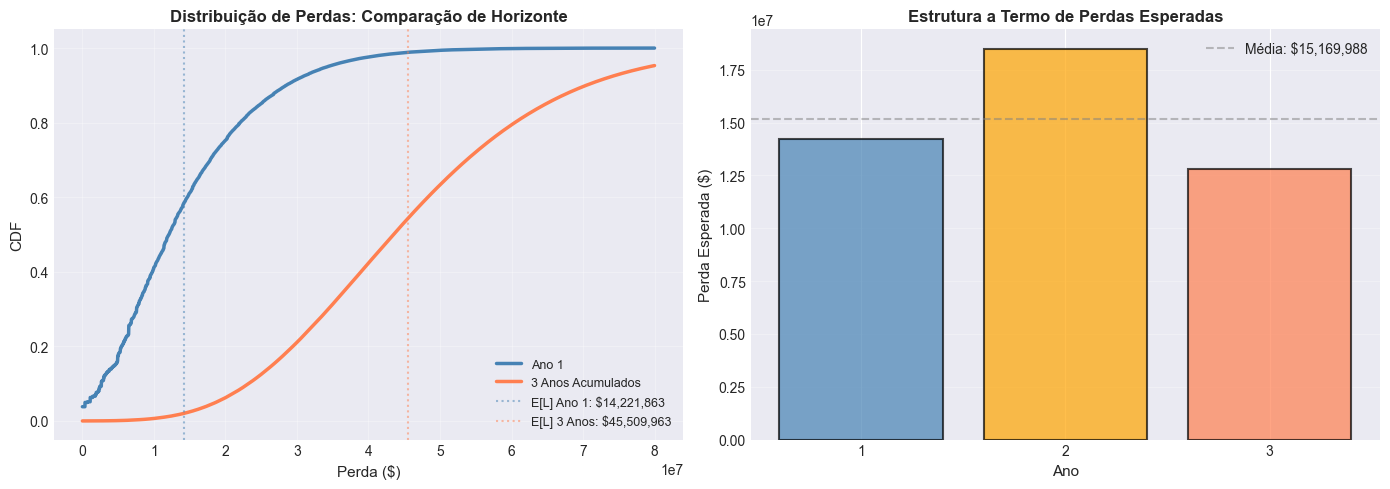

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Restringe para visualização
max_idx = min(np.searchsorted(cdf_3year, 0.999), 8000)
loss_vals = np.arange(max_idx) * unit_size

# CDF comparada
ax = axes[0]
ax.plot(loss_vals, cdf_1year[:max_idx], linewidth=2.5, label='Ano 1', color='steelblue')
ax.plot(loss_vals, cdf_3year[:max_idx], linewidth=2.5, label='3 Anos Acumulados', color='coral')
ax.axvline(el_by_year[1], color='steelblue', linestyle=':', alpha=0.5, label=f'E[L] Ano 1: ${el_by_year[1]:,.0f}')
ax.axvline(total_el_3years, color='coral', linestyle=':', alpha=0.5, label=f'E[L] 3 Anos: ${total_el_3years:,.0f}')
ax.set_xlabel('Perda ($)', fontsize=11)
ax.set_ylabel('CDF', fontsize=11)
ax.set_title('Distribuição de Perdas: Comparação de Horizonte', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Estrutura a termo de perda esperada
ax = axes[1]
years = sorted(el_by_year.keys())
els = [el_by_year[y] for y in years]
colors = ['steelblue', 'orange', 'coral']
ax.bar(years, els, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.axhline(total_el_3years/3, color='gray', linestyle='--', alpha=0.5, label=f'Média: ${total_el_3years/3:,.0f}')
ax.set_xlabel('Ano', fontsize=11)
ax.set_ylabel('Perda Esperada ($)', fontsize=11)
ax.set_title('Estrutura a Termo de Perdas Esperadas', fontsize=12, fontweight='bold')
ax.set_xticks(years)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Capital Econômico Multi-Ano

O capital econômico aumenta com o horizonte porque:
1. Mais tempo para defaults ocorrerem
2. Maior incerteza (volatilidade acumulada)

In [7]:
# Capital econômico a 99%
idx_99_1y = np.searchsorted(cdf_1year, 0.99)
loss_99_1y = idx_99_1y * unit_size
ec_99_1y = loss_99_1y - el_by_year[1]

idx_99_3y = np.searchsorted(cdf_3year, 0.99)
loss_99_3y = idx_99_3y * unit_size
ec_99_3y = loss_99_3y - total_el_3years

print("\n=== CAPITAL ECONÔMICO A 99% ===")
print(f"\nHorizonte 1 Ano:")
print(f"  VaR(99%):   ${loss_99_1y:>15,.0f}")
print(f"  E[Loss]:    ${el_by_year[1]:>15,.0f}")
print(f"  Capital:    ${ec_99_1y:>15,.0f}")

print(f"\nHorizonte 3 Anos:")
print(f"  VaR(99%):   ${loss_99_3y:>15,.0f}")
print(f"  E[Loss]:    ${total_el_3years:>15,.0f}")
print(f"  Capital:    ${ec_99_3y:>15,.0f}")

print(f"\nAumento de Capital: ${ec_99_3y - ec_99_1y:,.0f} ({(ec_99_3y - ec_99_1y)/ec_99_1y*100:.1f}%)")
print(f"\nRazão: O horizonte de 3 anos acumula risco, não apenas pela soma")
print(f"de E[L], mas pela convolutação de distribuições (cauda mais pesada).")


=== CAPITAL ECONÔMICO A 99% ===

Horizonte 1 Ano:
  VaR(99%):   $     46,470,000
  E[Loss]:    $     14,221,863
  Capital:    $     32,248,137

Horizonte 3 Anos:
  VaR(99%):   $     97,110,000
  E[Loss]:    $     45,509,963
  Capital:    $     51,600,037

Aumento de Capital: $19,351,901 (60.0%)

Razão: O horizonte de 3 anos acumula risco, não apenas pela soma
de E[L], mas pela convolutação de distribuições (cauda mais pesada).


## 8. Aplicações Práticas

O modelo multi-ano é importante para:

1. **Pricing de Crédito**: Calcular spread necessário para compensar risco ao longo da vida do empréstimo
2. **Provisões**: Estimar reservas necessárias para cobrir perdas em horizonte de hold-to-maturity
3. **Stress Testing**: Avaliar impacto de ciclos econômicos em diferentes períodos
4. **Regulação**: Solvência II, Basel III exigem análises multi-período